In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from alter_surf.hamiltonian_DLKK import H_DLKK_3D_MF, Spin_operator, points_BZ
from alter_surf.mean_field import hartree_fock

In [2]:
Hparam = dict(len_z=20,delta=1, tp=0.5, tz=1, U=10, filling=0.45, PBC= False)
Hparam = dict(len_z=2,delta=0.9, tp=0.3, tz=0., U=8, filling=0.5, PBC= True)
initial_parameters = dict(initial_m=(-1)**np.arange(Hparam['len_z'])/4, initial_n=Hparam['filling']*np.ones(Hparam['len_z']))

m_values, n_values, fermi_energys = hartree_fock(Hparam,initial_parameters, 40, Lq=30, tol_mdiff=1e-4,mixing_proportion=0.4,adjust_learning_rate=False)

Hparam['m_values'] = m_values[-1]
Hparam['n_values'] = n_values[-1]
Hparam['mu'] = fermi_energys[-1]


Avg:0.00, Stag. avg:0.44, diff: 0.000020:  32%|███▎      | 13/40 [00:00<00:00, 90.16it/s] 

filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5
filling:  0.5


Checking the convergence of the MF simualtion 

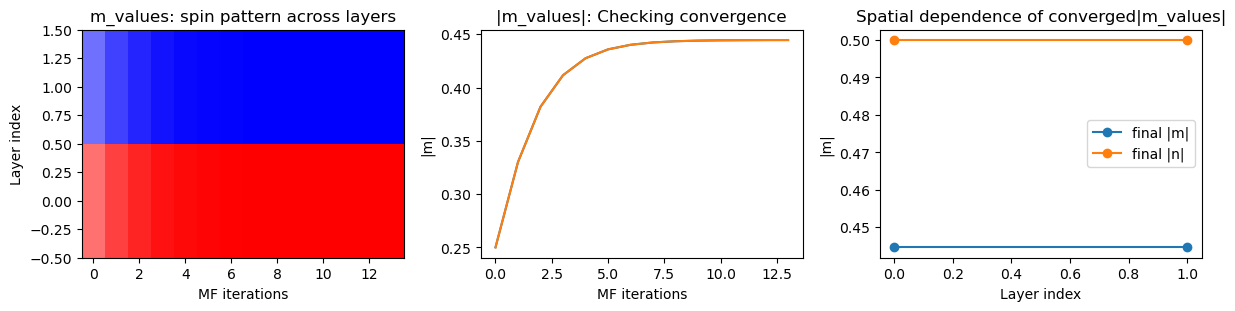

In [3]:
fig, axs = plt.subplots(1,3, figsize=(12,3), constrained_layout=True)

axs[0].set_title('m_values: spin pattern across layers')
axs[0].set_xlabel('MF iterations')
axs[0].set_ylabel('Layer index')
axs[0].imshow(m_values.T, aspect='auto', cmap='bwr',origin='lower', vmin=-m_values.max(), vmax=m_values.max())

axs[1].set_title('|m_values|: Checking convergence')
axs[1].set_xlabel('MF iterations')
axs[1].set_ylabel('|m|')
axs[1].plot(np.abs(m_values))

axs[2].set_title('Spatial dependence of converged|m_values|')
axs[2].set_xlabel('Layer index')
axs[2].set_ylabel('|m|')
axs[2].plot(np.abs(m_values[-1]),'-o',label='final |m|')
axs[2].plot(np.abs(n_values[-1]),'-o',label='final |n|')
axs[2].legend()

Now we need to check that it is acutally the lowest state in (free) energy. (Free in brackets because we are only interested in T=0) 

1) Compute the paramagnetic/ non-magnetic (PM) self consistent solution 

In [9]:
Hparam_PM = Hparam.copy()
Hparam_PM['mu'] = 0
initial_parameters_PM = dict(initial_m=np.zeros(Hparam['len_z']), initial_n=Hparam['filling']*np.ones(Hparam['len_z'])) #no magnetization
m_values_PM, n_values_PM, fermi_energys_PM = hartree_fock(Hparam_PM,initial_parameters_PM, 40, Lq=30, tol_mdiff=1e-4,mixing_proportion=0.4,adjust_learning_rate=False)
Hparam_PM['m_values'] = m_values_PM[-1]
Hparam_PM['n_values'] = n_values_PM[-1]
Hparam_PM['mu'] = fermi_energys_PM[-1]


print('n: ', n_values[-1].mean())

Avg:0.00, Stag. avg:0.00, diff: 0.000000:   5%|▌         | 2/40 [00:00<00:00, 48.70it/s]

filling:  0.5022222222222222
filling:  0.5022222222222222
filling:  0.5022222222222222
n:  0.5000000000000001


filling PM 0.5
filling AFM 0.5
-12.631387264163585 -0.8368862133106525


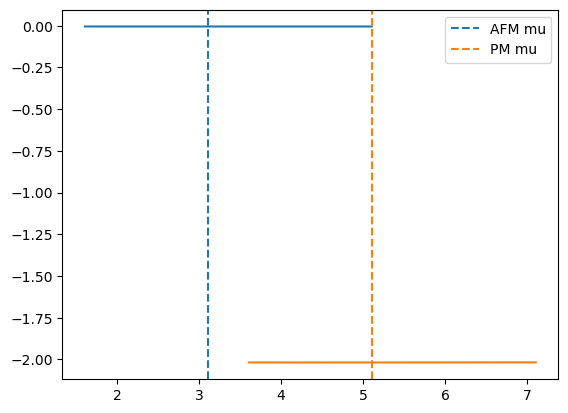

In [ ]:


from blochK.observable import eigs_H
from blochK.methods_basic import sample_reducedBZ

Lq = 40
ks = sample_reducedBZ(Lq)
es, psi = eigs_H(*ks, H_DLKK_3D_MF, Hparam)
es_PM, psi_PM = eigs_H(*ks, H_DLKK_3D_MF, Hparam_PM)

print('filling PM', np.sum(es_PM<0)/(Lq**2*4*Hparam_PM['len_z']))
print('filling AFM', np.sum(es<0)/(Lq**2*4*Hparam['len_z']))



dmus = np.linspace(-1.5,2,50)

e_tots  = []; e_tots_PM  = []

print(np.sum(es[es<0])/(Lq**2),-Hparam['U']*np.sum(Hparam['n_values']**2 - Hparam['m_values']**2))

for dmu in dmus:
    total_energy = np.sum(es[es<dmu])/(Lq**2) - Hparam['U']*np.sum(Hparam['n_values']**2 - Hparam['m_values']**2)
    total_energy_site = total_energy/(Hparam['len_z']*Lq**2)
    e_tots.append(total_energy)

    total_energy_PM = np.sum(es_PM[es_PM<dmu])/(Lq**2) - Lq**2*Hparam_PM['U']*np.sum(Hparam_PM['n_values']**2 - Hparam_PM['m_values']**2)
    total_energy_site_PM = total_energy_PM/(Hparam_PM['len_z']*Lq**2)
    e_tots_PM.append(total_energy_site_PM)

plt.plot(dmus + Hparam['mu'], e_tots)
plt.axvline(Hparam['mu'], color='C0', linestyle='--', label='AFM mu')

plt.plot(dmus + Hparam_PM['mu'], e_tots_PM)
plt.axvline(Hparam_PM['mu'], color='C1', linestyle='--', label='PM mu')

plt.legend()


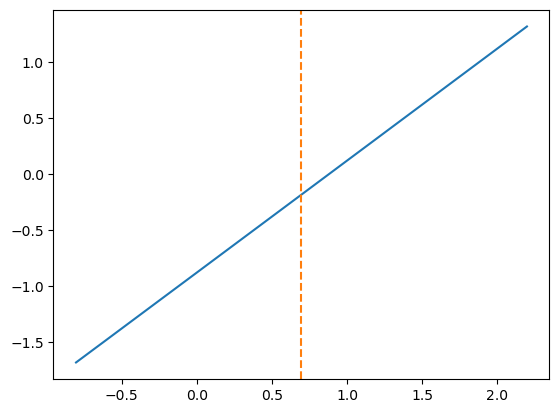

/Users/valentin/Documents/1_Promotion/Altermagnetism/Surface/alter_surf/src/blochK/plotting.py:65: UserWarning: No contour levels were found within the data range.
  FS0 = ax.contour(xs,ys,es[iband],[0],alpha=0)


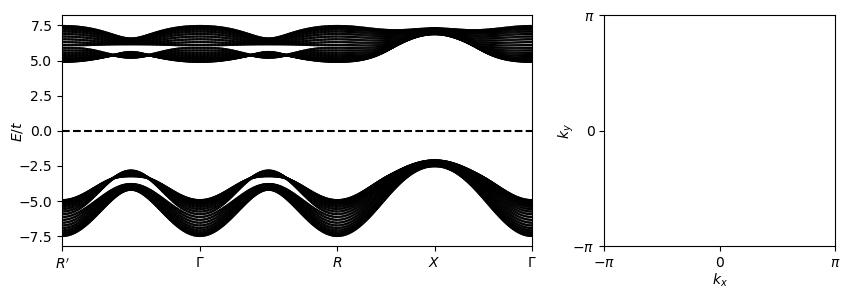

In [7]:
from blochK.plotting import plot_FS, plot_bandstruc

param = Hparam

labels = ["R'",'\Gamma','R',"X",'\Gamma']
pathBZ = np.array([points_BZ[x] for x in labels])
labels = ['$'+l+'$' for l in labels]

coloring_operator = np.kron(np.ones(param['len_z']), Spin_operator)

cmap = 'bwr'

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
plot_bandstruc(ax,H_DLKK_3D_MF,param=param,points_path=pathBZ,labels_points_path=labels,coloring_operator=coloring_operator,cmap=cmap)
plot_FS(ax1,H_DLKK_3D_MF,param=param,coloring_operator=coloring_operator,cmap=cmap,Lq=50)


      converged: True
           flag: 'converged'
 function_calls: 3
     iterations: 1
           root: 4.710115884242322